Git hub link: https://github.com/aansariieu2024-dev/ML-fundamentals-2026

In [1]:
from google.colab import files
files.upload()
import pandas as pd
df= pd.read_csv("bank-additional.csv", sep=";")
df.head()

Saving bank-additional.csv to bank-additional (8).csv


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


Task: Identifying the Prediction Target

y is our target variable, it is a binary outcome (yes or no) that tells us whether the client subscribed to a term deposit. The other variables in the dataset are the features that are used to predict y. The dataset contains the historical values of y which later will be used in training so that the trained model can be used for predictions when y is unknown.

In [2]:
print(df.columns.tolist())
df["y"].head()
x=df.drop(columns=["y"])
y= df["y"]
y.head()

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


,y
0,no
1,no
2,no
3,no
4,no


The two vairables from the dataset that apear to be valid targets are duration and poutcome.

Duration: This variable indicates the length of the clients last call which strongly correlates with the value of y. However it is not our prediction target as our aim is whether the client subscribes to a term deposit and not the length of the call.

poutcome: this varibale is the outcome of the previous campaign (success, failure, nonexistent), which may be apealing as the outcome of historical data could affect future behaviour however it is not our prediction target as it reflects a past campaign result and our objective is to predict the result of the current campaign.

Task: Data loading and exploration

The dataset (bank-additional.csv) has previously been uploaded.

In [3]:
from IPython.display import display

print("rows, columns", df.shape)
display(df.head())
print("Data types:")
display(df.dtypes)
print(" Basic summary statistics:")
display(df.describe(include="all").T)

rows, columns (4119, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


Data types:


,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


 Basic summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,4119.0,NaN,NaN,NaN,40.11362,10.313362,18.0,32.0,38.0,47.0,88.0
job,4119,12,admin.,1012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,4119,4,married,2509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,4119,8,university.degree,1264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,4119,3,no,3315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,4119,3,yes,2175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,4119,3,no,3349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,4119,2,cellular,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,4119,10,may,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,4119,5,thu,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN


After analysing the dataset we conclude that it contain 5 rows and 21 columns with both numerical and categorical variables.

In [4]:
categorical= df.select_dtypes(include="object").columns.tolist()
numerical= df.select_dtypes(exclude="object").columns.tolist()

categorical_num= len(categorical)
numerical_num= len(numerical)

print("categorical column:", categorical_num, "items", categorical)
print("numerical column:", numerical_num, "items", numerical)

categorical column: 11 items ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
numerical column: 10 items ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [5]:
count_target= df["y"].value_counts(dropna=False)
proportion_target= df["y"].value_counts(dropna=False, normalize=True)

print("target count", count_target)
print("target proportion", proportion_target)

target count y
no     3668
yes     451
Name: count, dtype: int64
target proportion y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64


According to the result, 89% of the clients did not subscribe to a term deposit while only 11% subscribed, therefore the target variable is class imbalanced. Because the majority class is no, a model that predicts no for all the clients would already achieve 89% accuracy, which can be misleading, therefore metrics such as recall and precision should also be used to evaluate performance on the minority class (y= yes).

In [6]:
missing_val_ex= df.isna().sum().sort_values(ascending=False)
missing_val_ex
missing_val_ex[missing_val_ex>0]

,0


As it can be seen from the code above, there is no explicit missing value in the dataset.

In [7]:
missing_val_imp= (df[categorical]=="unknown").sum().sort_values(ascending=False)
missing_val_imp
missing_val_imp[missing_val_imp>0]

,0
default,803
education,167
housing,105
loan,105
job,39
marital,11


Eventhough the dataset contains no explicit missing values (NAs), it includes implicit missingness saved as the special category unknown in several categorical variables. The largest number of unknown values are in default (803), education (167), housing (105), loan (105), job (39) and marital (11). The unknown values need to be handled before modelling.

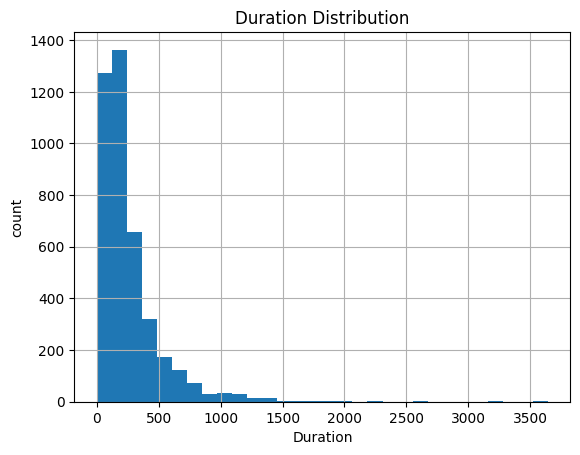

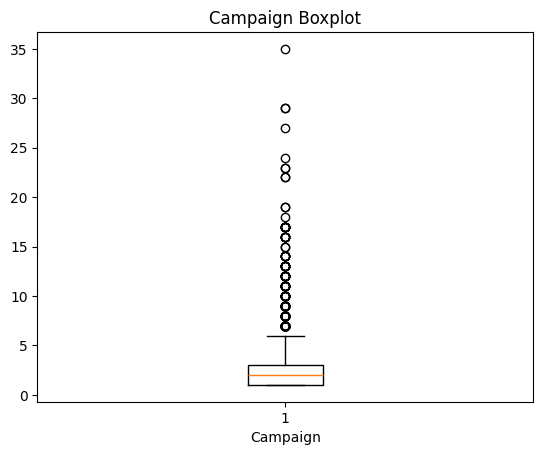

In [8]:
import matplotlib.pyplot as plt

df["duration"].hist(bins=30)
plt.title("Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("count")
plt.show()

plt.figure()
plt.boxplot(df["campaign"])
plt.title("Campaign Boxplot")
plt.xlabel("Campaign")
plt.show()


One of the numerical variables i chose was Duration because it reflects how the interaction with the client unfolded and could affect their subscription behaviour. I visualised this variable using a histogram because it clearly shows the overall distribution of a continuous variable. The plot is strongly right skewed, meaning most calls are short.

The second numerical variable i chose was Campaign because it shows the marketing effort and might influence subscription behaviour. I used a box plot as it highlights the srepad, median and outliers. The plot shows most clients were contacted a few times but a small number have very high contact counts shows as outliers indicating strong right skew.

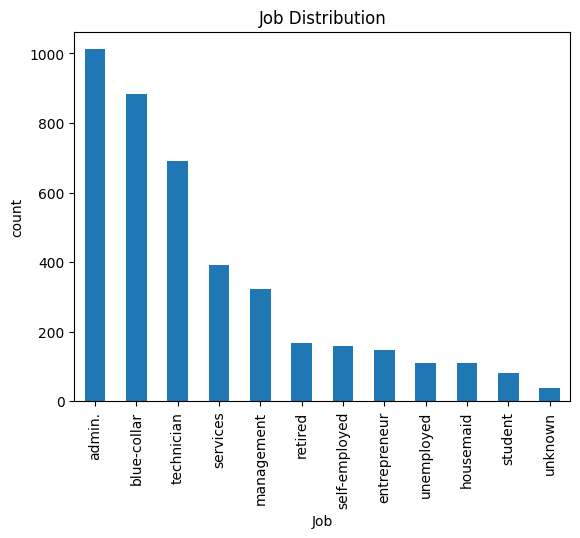

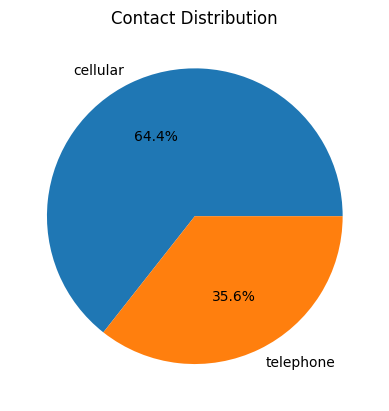

In [9]:
plt.figure()
df["job"].value_counts().plot(kind="bar")
plt.title("Job Distribution")
plt.xlabel("Job")
plt.ylabel("count")
plt.show()

plt.figure()
df["contact"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Contact Distribution")
plt.ylabel("")
plt.show()

I chose job as one of the categorical variables as it reflects the financial behaviour of the clients which could also affect their subsciption likelihood. The barchart shows uneven distribution with certain job groups dominating, the unknown special category also appears in the barchart.

The second categorical variable i chose was contact because it shows how the clients were contacted which could influence client engagement and subscription likelihood. The pie chart shows the majority of the contacts were made via cellular compared to telephone.

One variable that may require special consideration is duration. It represents the length of the call with the clients, this variable will be unknown at the time of the contact therefore its outcome will be unavailable for the prediction and it could affect the performance.
Another variable could be campaign, as it can be seen from the box plot its distribution is stongly right skewed which could negatively affect the model and need to be handled with special consideration.

Task: Data Splitting

The split has to happen after defining the target which is y and the inputs before any preprocessing. Otherwise steps such as encoding, imputing missing values, scaling, feature selection and resampling could cause data leakage by using information from validation and test set, this would lead to an overly optimistic performance reducing generalizability. For example imputation leakage occurs when the missing values are filled using data from the full dataset rather than the training set only, leading to an overly optimistic and less generizable outcome.

In [10]:
from sklearn.model_selection import train_test_split
target="y"
x= df.drop(columns=[target], errors="ignore")
y= df[target]

x_train,x_temporary,y_train,y_temporary=train_test_split(
    x,y, test_size=0.30, random_state=42, stratify=y)

x_validation, x_test, y_validation, y_test= train_test_split(
    x_temporary, y_temporary, test_size=0.50, random_state=42, stratify=y_temporary)

print("train", x_train.shape, y_train.shape)
print("validation", x_validation.shape, y_validation.shape)
print("test", x_test.shape, y_test.shape)

train (2883, 20) (2883,)
validation (618, 20) (618,)
test (618, 20) (618,)


I chose 70/15/15 as my proportions, I allocated most of the data to training as the dataset is not huge (4119 rows) and this way the model will better understand patterns. Meanwhile 15% is also large enough for validation to check performance during development especially as the target is imbalanced and needs enough data for the minority class. Similarly 15% for testing is also enough to use the model on unseen data and check its generalisation performance.

In [11]:
def show_props(name, y_part):
  proportions= (y_part.value_counts(normalize=True)*100).round(2)
  print(name, "proportions:", proportions)

show_props("dataset", y)
show_props("train", y_train)
show_props("validation", y_validation)
show_props("test", y_test)

dataset proportions: y
no     89.05
yes    10.95
Name: proportion, dtype: float64
train proportions: y
no     89.04
yes    10.96
Name: proportion, dtype: float64
validation proportions: y
no     89.0
yes    11.0
Name: proportion, dtype: float64
test proportions: y
no     89.16
yes    10.84
Name: proportion, dtype: float64


As shown before, the target variable is class imbalanced, with far more no than yes. Without stratification the train, validation and test set might randomly contain too few yes responses which could make the outcome biased and misleading. Stratification keeps the same proportion in each split as in the full dataset, making the performance more reliable. As it can be seen from the codes above, the proportion of yes and no are approximately the same in the full dataset, train, validation and test set.

Task: Managing Missing Values

This task is part of preprocessing, it identifies the missing values and helps us learn more about the data. It is performed after data splitting so that missing value handling decisions are fitted using the training set only to avoid data leakage.

In [12]:
missing_val_ex= df.isna().sum().sort_values(ascending=False)
missing_val_ex
print("explicit missing value:", missing_val_ex[missing_val_ex>0])

missing_val_imp= (df[categorical]=="unknown").sum().sort_values(ascending=False)
missing_val_imp
print("category(unknown):", missing_val_imp[missing_val_imp>0])

numerical= df.select_dtypes(exclude="object").columns.tolist()

sentinel_999= (df[numerical] == 999).sum().sort_values(ascending=False)
sentinel_999
print("sentinel 999\n", sentinel_999[sentinel_999>0])

sentinel_minus999= (df[numerical] == -999).sum().sort_values(ascending=False)
sentinel_minus999
print("sentinel - 999\n", sentinel_minus999[sentinel_minus999>0])

sentinel_minus1= (df[numerical] == -1).sum().sort_values(ascending=False)
sentinel_minus1
print("sentinel -1\n", sentinel_minus1[sentinel_minus1>0])

explicit missing value: Series([], dtype: int64)
category(unknown): default      803
education    167
housing      105
loan         105
job           39
marital       11
dtype: int64
sentinel 999
 pdays       3959
duration       1
dtype: int64
sentinel - 999
 Series([], dtype: int64)
sentinel -1
 Series([], dtype: int64)


As it can be seen above, the dataset has no explicit missing values.
I observed two forms of implicit missingness, special category unknown and sentinel number 999.
Unknowns appear in default(803), education(167), housing(105), loan(105), job(39) and marital(11).
Sentinel number 999 appear in pdays ( 3959), this variable represents the previous contact. It indicates no previous contact rather than a measurement of 999 days which is why it is a special value. This sentinel number also appears once in duration which could be an outlier rather than missingness as it has only occured once.

In [13]:
unknown_count= missing_val_imp[missing_val_imp>0]
unknown_percentage= (unknown_count/len(df))*100
unknown_percentage.round(2)

print("unknown count:", unknown_count)
print("unknown percentage:", unknown_percentage)

unknown count: default      803
education    167
housing      105
loan         105
job           39
marital       11
dtype: int64
unknown percentage: default      19.495023
education     4.054382
housing       2.549162
loan          2.549162
job           0.946832
marital       0.267055
dtype: float64


The implicit missingness ( unknown) varies in different categories, the largest proportion occurs in default where 803( 19.5%) are unknown.

In [14]:
sentinel_999_pdays_count= (df["pdays"] == 999).sum()
sentinel_999_pdays_percentage= round((sentinel_999_pdays_count / len(df)) * 100, 2)
print("pdays 999 count:", sentinel_999_pdays_count )
print("pdays 999 percentage:", sentinel_999_pdays_percentage)

sentinel_999_duration_count= (df["duration"] == 999).sum()
sentinel_999_duration_percentage= round((sentinel_999_duration_count / len(df)) * 100, 2)
print("duration 999 count:", sentinel_999_duration_count )
print("duration 999 percentage:", sentinel_999_duration_percentage)


pdays 999 count: 3959
pdays 999 percentage: 96.12
duration 999 count: 1
duration 999 percentage: 0.02


The sentinel number mostly appears in pdays where 3959 cases ( 96.12%) are 999. The value 999 only appears once in duration so it is more likely an outlier rather than missingness.

To handle the special category unknown, I would treat it as a seperate category rather than removing the rows especially in default variable as so many cases are unknown. Removing it would lead to losing predictive information and losing so many samples which is could influence the model in a negative way as the dataset inself is not large.

To handle the sentinel number(999) in pdays, I would treat it as a special code rather than a genuine 999. I would create an indicator feature that stores the clients that were never contacted before, replace 999 with missing values and impute pdays by replacing them with the median using training set statistics, which can be seen below.

For duration=999, as it has only occured once, it would be trate as an outlier not a missing values.


In [15]:
import pandas as pd
import numpy as np


for df_part in [x_train, x_validation, x_test]:
    columns_to_impute = [col for col in categorical if col in df_part.columns]
    df_part[columns_to_impute] = df_part[columns_to_impute].fillna("unknown")

for df_part in [x_train, x_validation, x_test]:
    df_part["never contacted before"] = (df_part["pdays"] == 999).astype(int)
    df_part["pdays"] = df_part["pdays"].replace(999, np.nan)

median_pdays = x_train["pdays"].median()

x_train["pdays"] = x_train["pdays"].fillna(median_pdays)
x_validation["pdays"] = x_validation["pdays"].fillna(median_pdays)
x_test["pdays"] = x_test["pdays"].fillna(median_pdays)

print("\nimputation:", median_pdays)


imputation: 5.0


Other than this step, any other preprocessing step that learns the patterns of the dataset need to be fitted using the training set only to avoid data leakage and not to affect the validation and test set. This includes steps such as imputation, encoding, feature selection and resampling, this way the model would be more generalizable and not overly optimistic.

Task: Encoding categorical variables

After splitting and handling missingness, the next step is encoding as some of the preprocessing steps that have to be done later need numerical variables therefore we need to convert the categorical variables first.

In [16]:
categorical= df.select_dtypes(include="object").columns.tolist()
categorical

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

The list of the categorical variables of the dataset can be seen above.

Education is ordinal because its category represents an educational level that has a meaningful order and it goes from lower to higher. We can encode it with increasing numbers that follow the progression.

All the other categorical variables, job, marital,default, housing, loan, contact, month, day:of:week and poutcome will be treated as nominal because they dont have a meaningful order.

y is the target variable so it would not be encoded as an input.

In [17]:
education_categories= sorted(x_train["education"].unique())
print(education_categories)

['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown']


In [18]:
ordinal_column= "education"
education_order= [
    "illiterate",
    "basic.4y",
    "basic.6y",
    "basic.9y",
    "high.school",
    "professional.course",
    "university.degree",
    "unknown"
]

education_final= {cat: i for i, cat in enumerate(education_order)}

for data in [x_train, x_validation, x_test]:
  data[ordinal_column]= data[ordinal_column].map(education_final)

x_train[ordinal_column].value_counts().sort_index()

,count
education,
0,1
1,292
2,155
3,396
4,661
5,376
6,890
7,112


I used ordinal encoding for education using increasing integers that follow the progression which keeps the natural ranking of education levels.

In [19]:
import pandas as pd

nominal_columns = ["job","marital","default","housing","loan","contact","month","day_of_week","poutcome"]

x_train_nominal = pd.get_dummies(x_train, columns=nominal_columns, drop_first=False)

x_value_nominal  = pd.get_dummies(x_validation, columns=nominal_columns, drop_first=False)
x_test_nominal = pd.get_dummies(x_test, columns=nominal_columns, drop_first=False)

x_value_nominal  = x_value_nominal.reindex(columns=x_train_nominal.columns, fill_value=0)
x_test_nominal = x_test_nominal.reindex(columns=x_train_nominal.columns, fill_value=0)

print("Before:", x_train.shape)
print("After:", x_train_nominal.shape)

Before: (2883, 21)
After: (2883, 57)


I used one hot encoding to the nominal categorical variables because they dont have an order. This type of encoding avoids introducing a ranking by rning each category into its own 0/1 feature. I encoded the training set and then fitted validation and test set to avoid leakage.

The result shows the features went from 20 to 56 because each categorical variable expanded into binary columns which improves interprebility because each coefficient is tied to a specific category but it also increases the number of features the model has to learn.

Both the ordinal and hot encoding must be done on the training set only so that the category mapping is learnt without using the validation and test set to avoid leakage.

Dimensionality of the dataset: One hot encoding increased the number of features ( 20 to 56) because each categorical variable expanded into binary columns and became its own feature. This could increase model complexity as it has to learn more features.

Interpretability of model coefficients:
As each coefficient corresponds to a specific category, one hot encoding makes logistic regression coefficients easier to interpret. It shows how belonging to that specific category affect the likelihood of subscription without creating an order.

Types of decision boundaries a linear model can represent:
Logistic regression learns linear decision boundary in the encoded feature space. One hot encoding assigns different weights to different categories wich increases flexibility but the decision boundary will remain linear.


Task: Feature scaling

Feature scaling is next becasue logistic regression is sensitive to feature scale especially when regularization is used. Scaling puts the non binary continuous features in a compatrable scale so that those with largers range would not dominate.

In [20]:
import numpy as np

numeric_columns = x_train_nominal.select_dtypes(include=[np.number]).columns
nonbinary_columns = [c for c in numeric_columns if not set(x_train_nominal[c].dropna().unique()).issubset({0, 1})]

print("Columns to scale:")
print(nonbinary_columns)

Columns to scale:
['age', 'education', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


I am scaling the non binary continuous variables that are shown above as these can have big ranges. These features could dominate logistic regression´s gradient based optimization.  

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = x_train_nominal.copy()
x_value_scaled   = x_value_nominal.copy()
x_test_scaled  = x_test_nominal.copy()

x_train_scaled[nonbinary_columns] = scaler.fit_transform(x_train_scaled[nonbinary_columns])

x_value_scaled[nonbinary_columns]  = scaler.transform(x_value_scaled[nonbinary_columns])
x_test_scaled[nonbinary_columns] = scaler.transform(x_test_scaled[nonbinary_columns])

x_train_scaled.shape, x_value_scaled.shape, x_test_scaled.shape

((2883, 57), (618, 57), (618, 57))

This shows standardization kept the number of features the same and only changed the values of continuous variables.

The reason I chose standardization was because it puts all the continuous variables on a comparable scale ( mean=0, sd=1). This makes gradient based optimization in logistic regression more stable and makes regularization treat the variables more fairly as the larger ranges would not dominate.

The feature scaling transformation must be fit on the training set only, the standardization parameters should be computed using the training data only. After the transformation, the fitted scaler is then applied to the validation and test sets to avoid leakage.

Gradient based optimization: Feature scaling improves the stability in logistic regression, because features have the same range the gradient would be more balanced and the result will be more reliable.

Magnitude and comparability of model coefficients: After standardization, the features have mean=0 and standard deviation=1 so they are presented in a comparable scale, making comparison between the magnitude of different features easier and more reliable. This process prevents features with large ranges from dominating the optimization.

Interpretation of regularization penalties:
Regularization prevents overfitting by penalizing the size of the coefficients. Without scaling regularization would treat the features unfairly because it may shrink a feature more because of its range and not because of its predictive power. After standardization, the features are on a similar scale so the penalty is applied more fairly.

Task: Feature Selection


So far we have done encoding and standardised the numerical variables therefore feature selection is next because variance checks are meaningful now. This step helps with the stability of logistic regression as it reduces redundancy.

In [22]:
low_variance_threshold = 0.01

variances = x_train_scaled.var().sort_values()

low_variance_features = variances[variances < low_variance_threshold].index.tolist()

print("Low variance threshold:", low_variance_threshold)
print("low variance features number:", len(low_variance_features))
print("low variances", low_variance_features)

x_train_lowvariance = x_train_scaled.drop(columns=low_variance_features, errors="ignore")
x_value_lowvariance   = x_value_scaled.drop(columns=low_variance_features, errors="ignore")
x_test_lowvariance  = x_test_scaled.drop(columns=low_variance_features, errors="ignore")

print("\nbefore:", x_train_scaled.shape, x_value_scaled.shape, x_test_scaled.shape)
print("after: ", x_train_lowvariance.shape, x_value_lowvariance.shape, x_test_lowvariance.shape)


Low variance threshold: 0.01
low variance features number: 4
low variances ['default_yes', 'marital_unknown', 'month_dec', 'job_unknown']

before: (2883, 57) (618, 57) (618, 57)
after:  (2883, 53) (618, 53) (618, 53)


I chose 0.01 as the variance threshold because after doing one hot encoding many categorical variables were represented as binary dummy variables. Their variance ( p(1-p) ) depends on p which is the proportion of rows that have value 1 in that feature. When the variance is less than 0.01, it means that the category is either very rare which provides little information or very common which acts like a constant, therefore the best way to deal with them is to drop them to make logistic regression more stable.

In [23]:
import numpy as np

numeric_columns = x_train_nominal.select_dtypes(include=[np.number]).columns
nonbinary_columns = [c for c in numeric_columns if not set(x_train_nominal[c].dropna().unique()).issubset({0, 1})]

print(nonbinary_columns)

['age', 'education', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [24]:
correlation_threshold = 0.90

correlation_matrix = x_train_scaled[nonbinary_columns].corr().abs()

upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

high_correlation_pairs = (
    upper_triangle.stack()
         .reset_index()
         .rename(columns={"level_0":"var1", "level_1":"var2", 0:"correlation"})
)

high_correlation_pairs = high_correlation_pairs[high_correlation_pairs["correlation"] > correlation_threshold] \
                   .sort_values("correlation", ascending=False)

high_correlation_pairs

,var1,var2,correlation
47,emp.var.rate,euribor3m,0.969648
54,euribor3m,nr.employed,0.942087


In [25]:
to_drop_correlated = ["euribor3m"]

x_train_correlated = x_train_lowvariance.drop(columns=to_drop_correlated, errors="ignore")
x_value_correlated   = x_value_lowvariance.drop(columns=to_drop_correlated, errors="ignore")
x_test_correlated  = x_test_lowvariance.drop(columns=to_drop_correlated, errors="ignore")

x_train_correlated.shape, x_value_correlated.shape, x_test_correlated.shape

((2883, 52), (618, 52), (618, 52))

I decided to use 0.90 as my threshold because it identifies highly correlated features, a value close to 1 shows very strong linear relationship which could disrupt the logistic regression and make it unstable. After using this threshold I found two pairs that were very correlated, whcih variable euribor3m appeared in both pairs meaning it is highly correlated with both emp.var.rate and nr.employed, therefore I decided to drop that variable to reduce multicollinearity.

In [26]:
conceptual_drop = ["duration", "index"]
x_train_conceptual = x_train_correlated.drop(columns=conceptual_drop, errors="ignore")
x_value_conceptual   = x_value_correlated.drop(columns=conceptual_drop, errors="ignore")
x_test_conceptual  = x_test_correlated.drop(columns=conceptual_drop, errors="ignore")

x_train_conceptual.shape, x_value_conceptual.shape, x_test_conceptual.shape

((2883, 51), (618, 51), (618, 51))

As it can be seen above I also dropped variables duration and index.
Duration was dropped as it shows the length of the calls with the clients which is known after the call ends therefore we do not know its outcome at the time of the contact to use for prediction purposes, using it would make the performance unrealistic and cause target leakage. Excluding it from the dataset would be the best decision for better prediction results.
Index was dropped as it does not represent information about the client or the campaign which would not help predict the likelihood of the client´s subscription.

Feature selection also needs to be performed using the training set only because it uses statistical computations such as variance and correlations which need to be done using training data to avoide data leakage and creating an overly optimistic model. If we use the full dataset we would use data from validation and test set aswell which could affect the generalizability of the model.

One of the consequences of performing feature selection on the entire dataset before splitting is causing data leakage as you would use the data from both the validation and test set which is supposed to be unseen data to test your model on. Another one is creating an overly optimistic model as you would use information from validation and test set aswell and it would decrease the generalizability of the model as the model would overly specific for the dataset.

Task: Addressing Class Imbalance

This task is next as we are done with most of the preprocessing steps so any imbalance resampling should be done now as part of training procedure before fitting logistic regression.

In [27]:
y_train.value_counts(), (y_train.value_counts(normalize=True)*100).round(2)

(y
 no     2567
 yes     316
 Name: count, dtype: int64,
 y
 no     89.04
 yes    10.96
 Name: proportion, dtype: float64)

As shown, the training set is imbalanced, about 89% of the target values are no while only 11% are yes. This can be problematic, because a model can achieve high accuracy( 89%) simply by predicting no, yet perform poorly at detecting clients who actually subscribe (yes).

In [28]:
from imblearn.over_sampling import RandomOverSampler

x_train_final = x_train_conceptual
y_train_final = y_train

sampler= RandomOverSampler(random_state=42)
x_train_resampled, y_train_resampled = sampler.fit_resample(x_train_final, y_train_final)

print("Before:\n", y_train_final.value_counts())
print("\nAfter:\n", y_train_resampled.value_counts())

Before:
 y
no     2567
yes     316
Name: count, dtype: int64

After:
 y
no     2567
yes    2567
Name: count, dtype: int64


I applied random oversampling to my training set as my resampling strategy. It duplicated the minority class (yes) to balance the classes. I performed this step after preprocessing( missing value handling, encoding categorical variables, scaling and feature selection) and before fitting logistic regression. Resampling is not done on validation and test set as they use the original dataset and class dirstribution for a fair and reliable analysis.

The reason I chose ramdom oversampling was because, this technique increases the number of the minority class(yes) by duplicating existing samples. This is a better way compared to SMOTE or ADASYN as they use interpolation which could create fractional values which are not appropriate for our case as many features are binary one hot encoded. Balancing the classes improves the model´s ability to detect the minority class (recall)  and would improves performance. This would also help us learn the algorithm better. On the other hand it may increase the risk of overfitting the duplicated samples.

If resampling is done before splitting, the duplicated samples would be included in the validation and test set aswell which could cause data leakage, make an overly optimistic model and decrease its generalizability.

Class imbalance makes accuracy misleading because if the model predicts the majority class(no) all the time, it could reach in this case 89% accuracy eventhough the model would fail to detect the minority class. Precision refers to the proportion of predicted minority class that are actually yes and recall refers to the number of minority class the model finds successfully, therefore both focus on the minority class, having an imbalanced class makes these factors more important and their values low due to the model favouring the majority class.

Task: Training a Logistic Regression Model

In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=3000, random_state=42)
lr.fit(x_train_resampled, y_train_resampled)

LogisticRegression(max_iter=3000, random_state=42)

In [30]:
x_value_final = x_value_conceptual

x_value_prediction = lr.predict(x_value_final)

print(x_value_prediction)

['no' 'yes' 'no' 'no' 'no' 'no' 'yes' 'yes' 'no' 'no' 'no' 'no' 'no' 'yes'
 'no' 'no' 'no' 'no' 'no' 'yes' 'no' 'no' 'no' 'no' 'yes' 'no' 'yes' 'no'
 'no' 'no' 'no' 'no' 'yes' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no'
 'no' 'no' 'no' 'yes' 'yes' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'yes'
 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'yes' 'no' 'no'
 'no' 'no' 'yes' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'yes' 'yes' 'no' 'no'
 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'yes' 'no' 'no' 'no'
 'no' 'no' 'no' 'yes' 'yes' 'no' 'no' 'no' 'no' 'no' 'yes' 'no' 'no' 'no'
 'no' 'no' 'no' 'no' 'no' 'yes' 'yes' 'no' 'no' 'no' 'no' 'yes' 'no' 'no'
 'no' 'no' 'no' 'no' 'no' 'yes' 'yes' 'no' 'no' 'no' 'no' 'yes' 'yes' 'no'
 'yes' 'no' 'no' 'no' 'no' 'yes' 'no' 'no' 'no' 'no' 'yes' 'no' 'no' 'yes'
 'yes' 'no' 'yes' 'no' 'no' 'yes' 'no' 'no' 'yes' 'no' 'no' 'yes' 'yes'
 'no' 'no' 'no' 'yes' 'no' 'yes' 'no' 'no' 'no' 'yes' 'no' 'no' 'no' 'no'
 'yes' 'no' 'no' 'no' 'no' 'no' 'no' 'no' '

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy  = accuracy_score(y_validation, x_value_prediction)
precision = precision_score(y_validation, x_value_prediction, pos_label="yes")
recall  = recall_score(y_validation, x_value_prediction, pos_label="yes")

print(f"Validation Accuracy : {accuracy:.4f}")
print(f"Validation Precision: {precision:.4f}")
print(f"Validation Recall   : {recall:.4f}")

Validation Accuracy : 0.8317
Validation Precision: 0.3525
Validation Recall   : 0.6324


Interpretation:
Accuracy: Successfully predicts 83% of the cases.
Precision: Out of the subscribers the model predicts, 35% actually subscribe.
Recall: Out of all actual subscribers, the model predicts 63% of them.

In [32]:
from sklearn.metrics import confusion_matrix
import pandas as pd

confusion_m = confusion_matrix(y_validation, x_value_prediction, labels=["no","yes"])
pd.DataFrame(confusion_m, index=["Actual no","Actual yes"], columns=["Prediction no","Prediction yes"])

,Prediction no,Prediction yes
Actual no,471,79
Actual yes,25,43


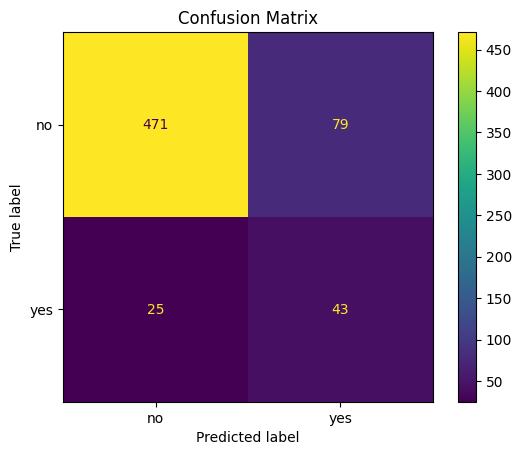

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

display = ConfusionMatrixDisplay(confusion_matrix=confusion_m, display_labels=["no","yes"])
display.plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that 471 cases were true negatives, 79 cases were false positives, 25 cases were false negatives and 43 cases were true positives.

In [34]:
import numpy as np
from sklearn.metrics import accuracy_score

yzero = np.array(["no"] * len(y_validation))
zero_accuracy = accuracy_score(y_validation, yzero)

print(f"Zero Rule Baseline Accuracy: {zero_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

Zero Rule Baseline Accuracy: 0.8900
Logistic Regression Accuracy: 0.8317


The Model´s accuracy is 0.8317 and the zero rule baseline accuracy is 0.8900, which is higher, this is because zero rule baseline predicts the majority class(no) which increases the accuracy but it could be misleading. Logistic regression predicts more "yes" cases which increases false positive and decreases accuracy. Therefore the more effective way of judging the logistic regression is through precision and recall as they focus on the minority class.

Task: Task ordering

1. Identifying the Prediction Target

The variables in the dataset that are available at the contact time are allowed to be used at this step, but the variables that are unknown at the prediction time are not allowed at this step (duration).
Target leakage could occur at this step if the variables that are unknown at the prediction time are part of this step.

2. Data loading and exploration

What is allowed at this step is plotting to understand the distribution of the variables. What is not allowed is making decisions using statistics from the full dataset. Data leakage would happen at this step if you make statistical and preprocessing decisions on the full dataset before splitting it into training, validation and test set.

3. Data Splitting

What is allowed at this step is the stratification of only variable y so that the proportions are the same across the sets. What is not allowed is doing any preprocessing before the splitting. This could cause extreme data leakage as all the sets will get affected, making the model overly optimistic.

4. Managing Missing Values
What is allowed at this step is handling the missing values only with the training data, in my case i did imputation only using training data and dealt with unknowns that existed only in the training set. What is not allowed is using the full dataset for imputation or any other missingness handling decisions. This could cause imputation leakage which could decrease the generalizability of the model.


5. Encoding Categorical Variables

What is allowed at this step is encoding the categorical variables based on only the training set. What is not allowed is validation and test sets affecting the encoding. This could cause encoding leakage which will lead to an overly optimistic model.

6. Feature Scaling

What is allowed at this step is doing the scaling on only the training set for example the standardization. What is not allowed is using the full dataset for scaling. This could cause scaling leakage and make the model overly optimistic.

7. Feature Selection

What is allowed at this step is computing the variance and correlation on the training set, what is not allowed is using the full dataset to compute the variance and correlation. This could cause selection leakage which gives overly optimistic results.

8. Addressing Class Imbalance

What is allowed at this step is resampling the class imbalance in the training set only and what is not allowed is resampling the full dataset. This could lead to data leakage as the duplicated samples would also be in the validation and test set making the model unrealistic.

9. Training a Logistic Regression Model

What is allowed at this step is training the logistic regression on the training data, what is not allowed is training it on the full dataset. This could lead to leakage as you could not use the validation and test set to test the generalizability of the model.

I decided the identification of the prediction target to be first so that I know the input features and my target to then split the data and do the preprocessing steps to get the data ready for Logistic Regression. After this step data loading and exploration was necessary so that I would analyse the dataset I had and the variables in it. After ths step I chose to do data splitting as it had to be done before any preprocessing step so that the training set would be separated from the validation and test sets, this way the data for validation and test sets would be from the original dataset without any transformations for a more reliable result. Managing missing values was next so that the values in each variable would be ready for further computations. After this step I encoded the categorical variables as the other steps in preprocessing need numerical variables therefore I had to have the dummy variables ready before I proceed. Feature scaling was after because there were so many numerical variables in my dataset that had different ranges and for a better and fair result I had to stardardize them before doing the feature selection. Feature selection was before addressing the inclass imbalance as the variables with low variances had to be dropped to reduce noise before resampling. Resampling the class imbalance was the last step before training the logistic regression model as having a more balanced data would improve minority class performance.

One example of incorrect resampling is placing data splitting after the preprocessing steps for instance after addressing the class imbalance. This would change the whole dataset and would affect the validation and test sets which are supposed to be untouched so that the model would be tested on them. The duplicates samples would also apear in the validation and test sets.  This would decrease the generalizability of the model, making it overly optimistic and unreliable on unseen data.  